<a href="https://colab.research.google.com/github/springboardmentor891v/CreditPathAI/blob/Rajath/notebooks/pre_processing__methods1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#pip install numpy==1.23.5

In [ ]:
import pandas as pd
import numpy as np
import cufflinks as cf
import plotly.offline
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
# Set up the connection to Plotly
cf.go_offline()

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/My Drive/Loan_Default.csv')

Mounted at /content/drive


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

In [ ]:
df.Status.unique()

array([1, 0])

In [ ]:
df.describe()

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
count,148670.000000,148670.0,1.486700e+05,112231.000000,112031.000000,109028.000000,148629.000000,1.335720e+05,139520.000000,148670.000000,133572.000000,148670.000000,124549.000000
mean,99224.500000,2019.0,3.311177e+05,4.045476,0.441656,3224.996127,335.136582,4.978935e+05,6957.338876,699.789103,72.746457,0.246445,37.732932
std,42917.476598,0.0,1.839093e+05,0.561391,0.513043,3251.121510,58.409084,3.599353e+05,6496.586382,115.875857,39.967603,0.430942,10.545435
min,24890.000000,2019.0,1.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,0.000000,5.000000
25%,62057.250000,2019.0,1.965000e+05,3.625000,0.076000,581.490000,360.000000,2.680000e+05,3720.000000,599.000000,60.474860,0.000000,31.000000
50%,99224.500000,2019.0,2.965000e+05,3.990000,0.390400,2596.450000,360.000000,4.180000e+05,5760.000000,699.000000,75.135870,0.000000,39.000000
75%,136391.750000,2019.0,4.365000e+05,4.375000,0.775400,4812.500000,360.000000,6.280000e+05,8520.000000,800.000000,86.184211,0.000000,45.000000
max,173559.000000,2019.0,3.576500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,578580.000000,900.000000,7831.250000,1.000000,61.000000


In [ ]:
df=df.drop(['ID','year'],axis=1)

In [ ]:
df.head(5)

,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,loan_amount,rate_of_interest,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,116500,NaN,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,cf,Male,nopre,type2,p1,l1,nopc,b/c,206500,NaN,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,cf,Male,pre,type1,p1,l1,nopc,nob/c,406500,4.56,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,cf,Male,nopre,type1,p4,l1,nopc,nob/c,456500,4.25,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,cf,Joint,pre,type1,p1,l1,nopc,nob/c,696500,4.00,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


# description of the features

* loanlimit(A conforming mortgage means it meets the loan limits)The current maximum loan limit in most U.S. counties is $417,000
* gender(male,joint, not available)
* approv_in_adv (nopre,pre) pre-approval is a preliminary evaluation of a potential borrower by a lender to determine whether they are likely to be approved for a loan
* loan_type (type1,type2,type3 )type3 is the largest amount of money among them
* loan_purpose (p1,p3,p4)
* Credit_Worthiness
* The loan-to-value (LTV) ratio is a lending risk assessment ratio that financial institutions and other lenders examine before approving a mortgage


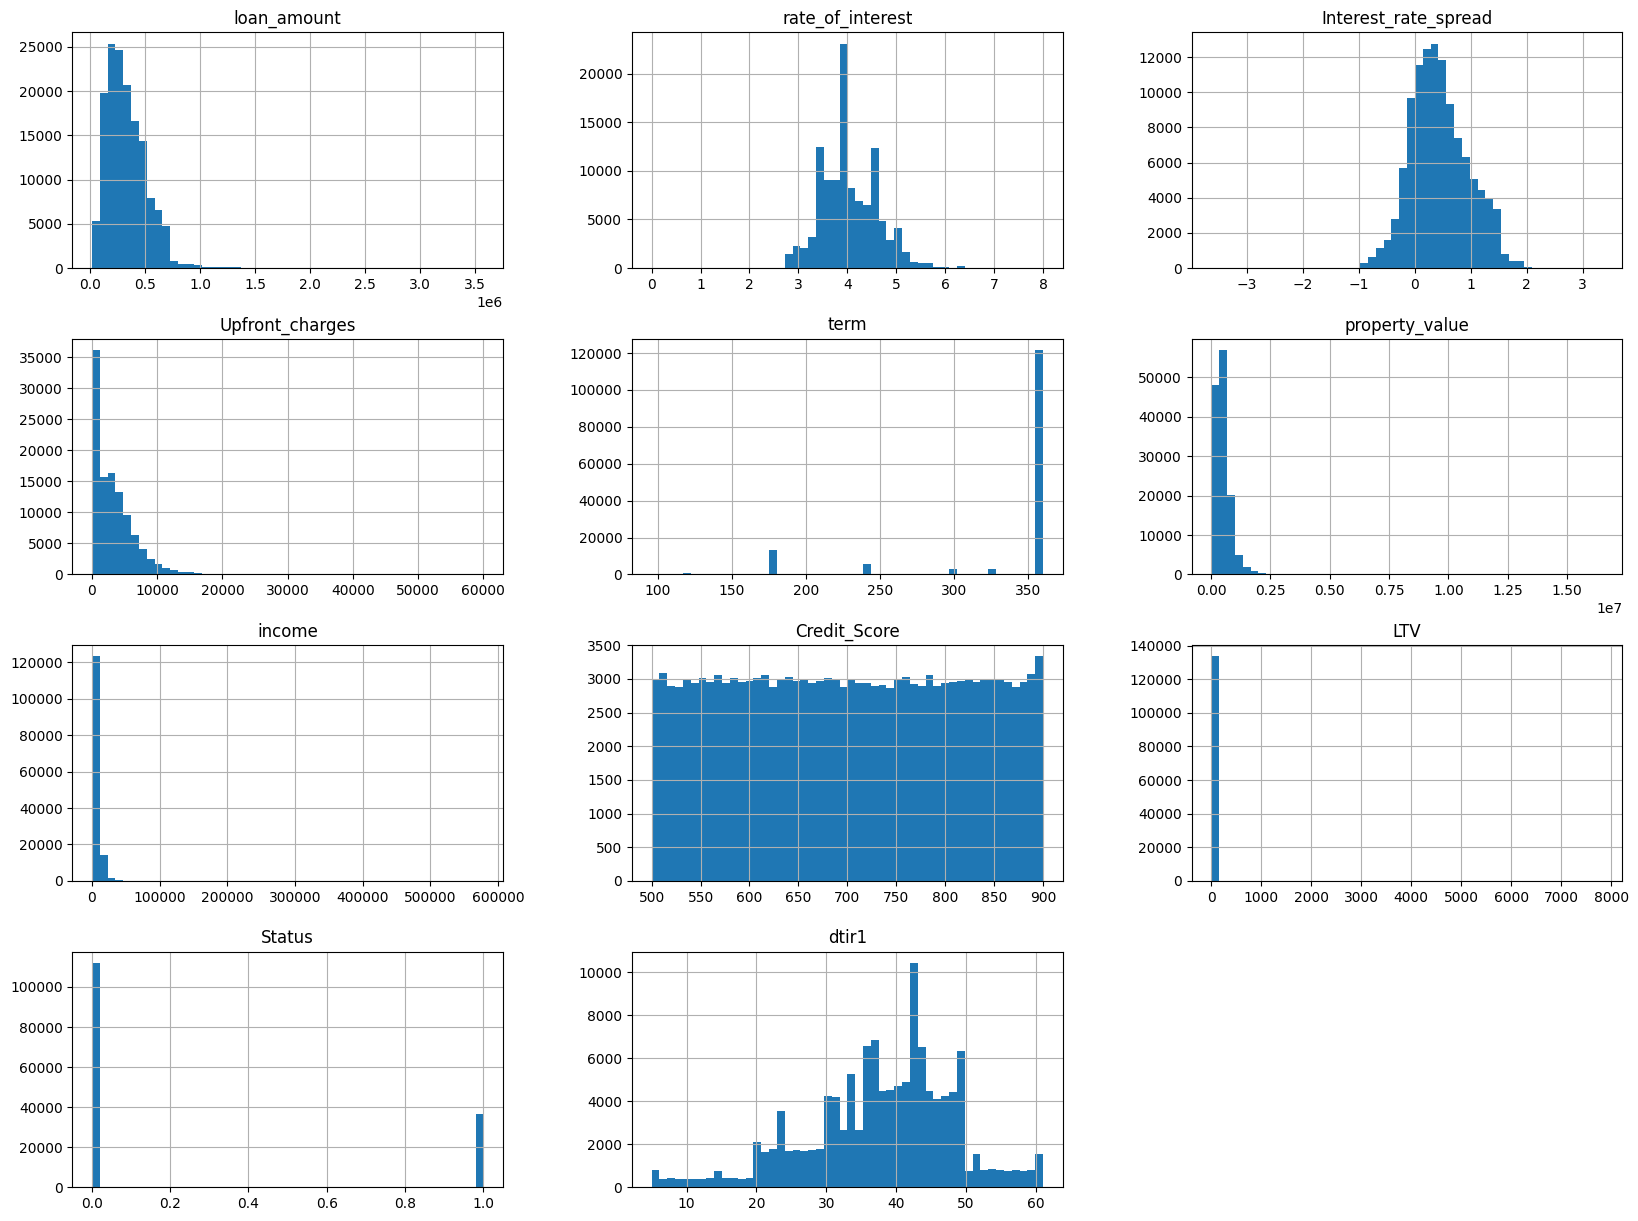

In [ ]:
# Numerical data histogram to show the distribution  balance of data and ranges
df.hist(bins = 50, figsize = (20, 15))
plt.show()

In [ ]:
df.isnull().sum()

,0
loan_limit,3344
Gender,0
approv_in_adv,908
loan_type,0
loan_purpose,134
Credit_Worthiness,0
open_credit,0
business_or_commercial,0
loan_amount,0
rate_of_interest,36439


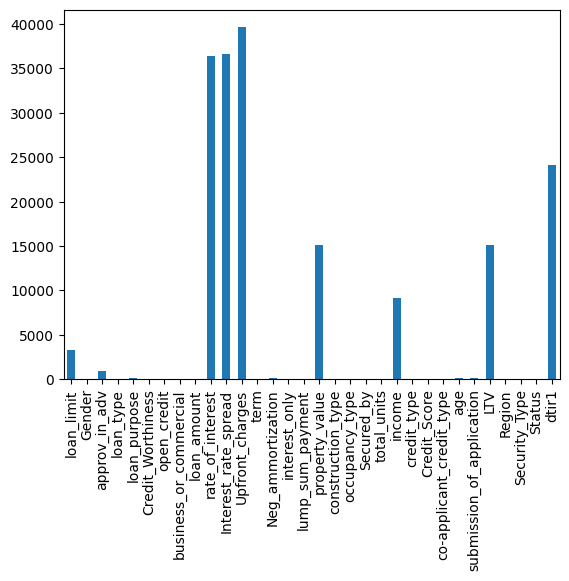

In [ ]:
df.isna().sum().plot.bar()
plt.show()

null values in some features scores apploxematly 27%(the maximum ) of total data

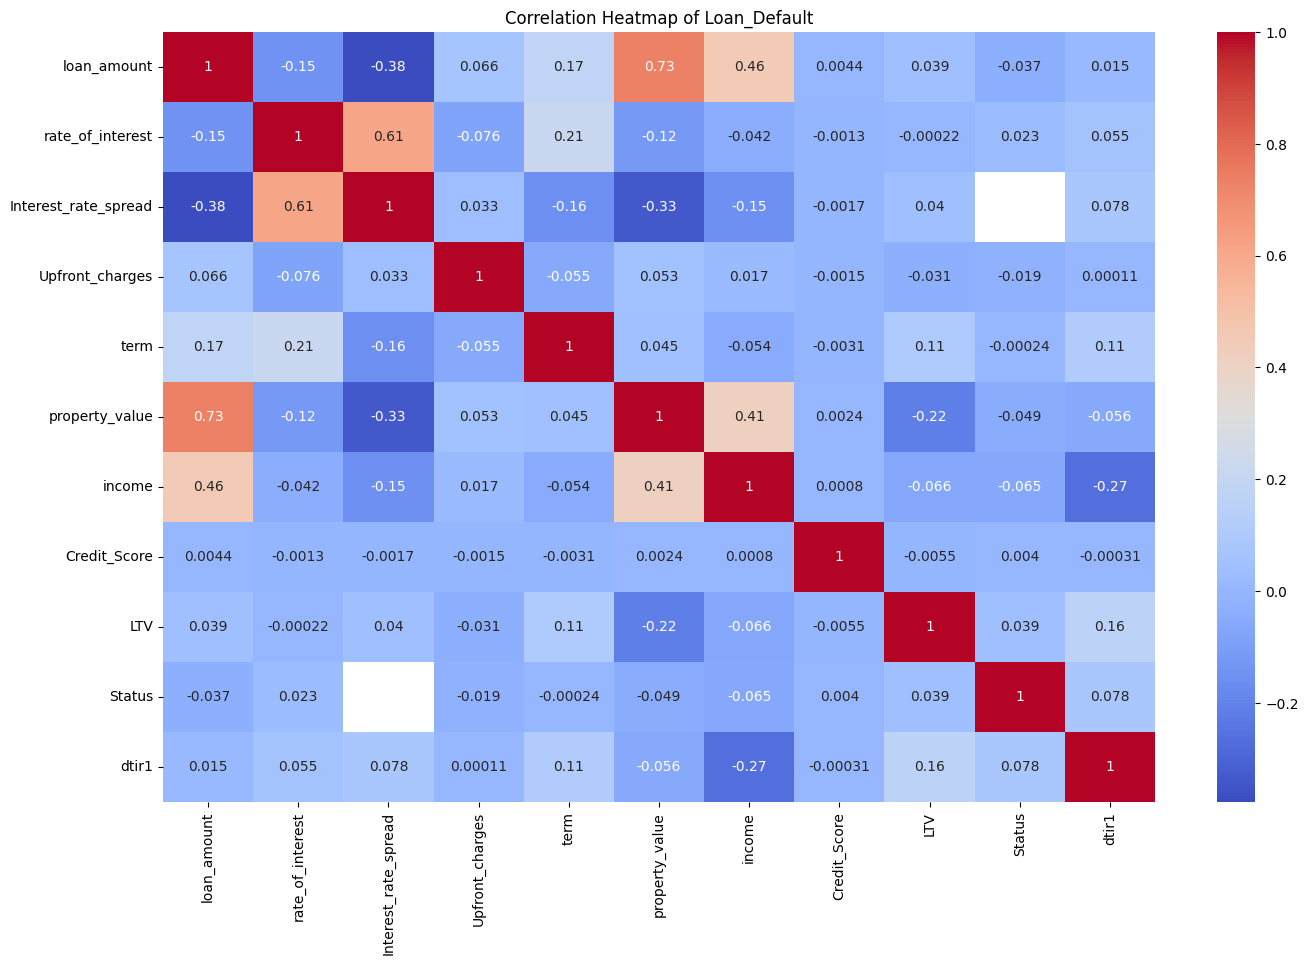

In [ ]:

# Select only numerical columns for the heatmap
numerical_cols = df.select_dtypes(include=['number'])

# Create a correlation matrix
correlation_matrix = numerical_cols.corr()

# Create a heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Loan_Default')
plt.show()

In [ ]:
num=[]
for x in df:
    if df[x].dtype == 'int64' or df[x].dtype == 'float64':
        num.append(x)


print("numerical col :",num)

numerical col : ['loan_amount', 'rate_of_interest', 'Interest_rate_spread', 'Upfront_charges', 'term', 'property_value', 'income', 'Credit_Score', 'LTV', 'Status', 'dtir1']


In [ ]:
cat=[]
for x in df.columns:
    if df[x].dtype == 'object':
        cat.append(x)


print("categorical col :",cat)

categorical col : ['loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'Credit_Worthiness', 'open_credit', 'business_or_commercial', 'Neg_ammortization', 'interest_only', 'lump_sum_payment', 'construction_type', 'occupancy_type', 'Secured_by', 'total_units', 'credit_type', 'co-applicant_credit_type', 'age', 'submission_of_application', 'Region', 'Security_Type']


In [ ]:
'''columns_to_check = [
    'open_credit', 'loan_limit', 'approv_in_adv', 'credit_worthiness',
    'business_or_commercial', 'neg_ammortization', 'interest_only',
    'lump_sum_payment', 'construction_type', 'secured_by',
    'submission_of_application', 'security_type'
]

for col in columns_to_check:
    print(f"Value counts for '{col}':")
    print(df[col].value_counts())
    print("\n" + "="*30 + "\n")'''

Value counts for 'open_credit':
open_credit
nopc    148114
opc        556
Name: count, dtype: int64


Value counts for 'loan_limit':
loan_limit
cf     135348
ncf      9978
Name: count, dtype: int64


Value counts for 'approv_in_adv':
approv_in_adv
nopre    124621
pre       23141
Name: count, dtype: int64


Value counts for 'credit_worthiness':


KeyError: 'credit_worthiness'

the most needed loan is is from type1 and thethe amount nearly(200k to 400k)


In [ ]:
#null values numerical
for i in df.columns:
    print(i ,":" ,df[i].unique())

loan_limit : ['cf' nan 'ncf']
Gender : ['Sex Not Available' 'Male' 'Joint' 'Female']
approv_in_adv : ['nopre' 'pre' nan]
loan_type : ['type1' 'type2' 'type3']
loan_purpose : ['p1' 'p4' 'p3' 'p2' nan]
Credit_Worthiness : ['l1' 'l2']
open_credit : ['nopc' 'opc']
business_or_commercial : ['nob/c' 'b/c']
loan_amount : [ 116500  206500  406500  456500  696500  706500  346500  266500  376500
  436500  136500  466500  226500   76500  356500  156500  586500  306500
  316500  336500  426500  476500  196500  186500  246500  216500  506500
  656500  256500  396500  166500  236500  866500  416500  386500  596500
  606500   86500  286500  146500  446500  636500  486500  326500   56500
  906500  496500  106500  126500  296500  176500 1376500  566500  686500
  556500  676500  366500  276500  716500   66500  616500   96500  826500
   26500  666500  546500  986500  526500 1226500  726500 1486500 1416500
  536500  796500  516500   46500  876500  576500  626500 1506500  886500
  816500  646500  776500  7

In [ ]:
from sklearn.impute import SimpleImputer
mean_imputer = SimpleImputer(strategy='mean')
df[num] = mean_imputer.fit_transform(df[num])
#do median here . there will be no backfire

In [ ]:
df.Status.unique()

array([1., 0.])

In [ ]:
for i in cat:
    mode=df[i].mode()
    mode=mode[0]
    df[i].fillna(value=mode,inplace=True)


/tmp/ipython-input-1146906669.py:4: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [ ]:
df[cat].isnull().sum()

,0
loan_limit,0
Gender,0
approv_in_adv,0
loan_type,0
loan_purpose,0
Credit_Worthiness,0
open_credit,0
business_or_commercial,0
Neg_ammortization,0
interest_only,0


In [ ]:
df[num].isnull().sum()

,0
loan_amount,0
rate_of_interest,0
Interest_rate_spread,0
Upfront_charges,0
term,0
property_value,0
income,0
Credit_Score,0
LTV,0
Status,0


,0
loan_amount,"Axes(0.125,0.747241;0.227941x0.132759)"
rate_of_interest,"Axes(0.398529,0.747241;0.227941x0.132759)"
Interest_rate_spread,"Axes(0.672059,0.747241;0.227941x0.132759)"
Upfront_charges,"Axes(0.125,0.587931;0.227941x0.132759)"
term,"Axes(0.398529,0.587931;0.227941x0.132759)"
property_value,"Axes(0.672059,0.587931;0.227941x0.132759)"
income,"Axes(0.125,0.428621;0.227941x0.132759)"
Credit_Score,"Axes(0.398529,0.428621;0.227941x0.132759)"
LTV,"Axes(0.672059,0.428621;0.227941x0.132759)"
Status,"Axes(0.125,0.26931;0.227941x0.132759)"


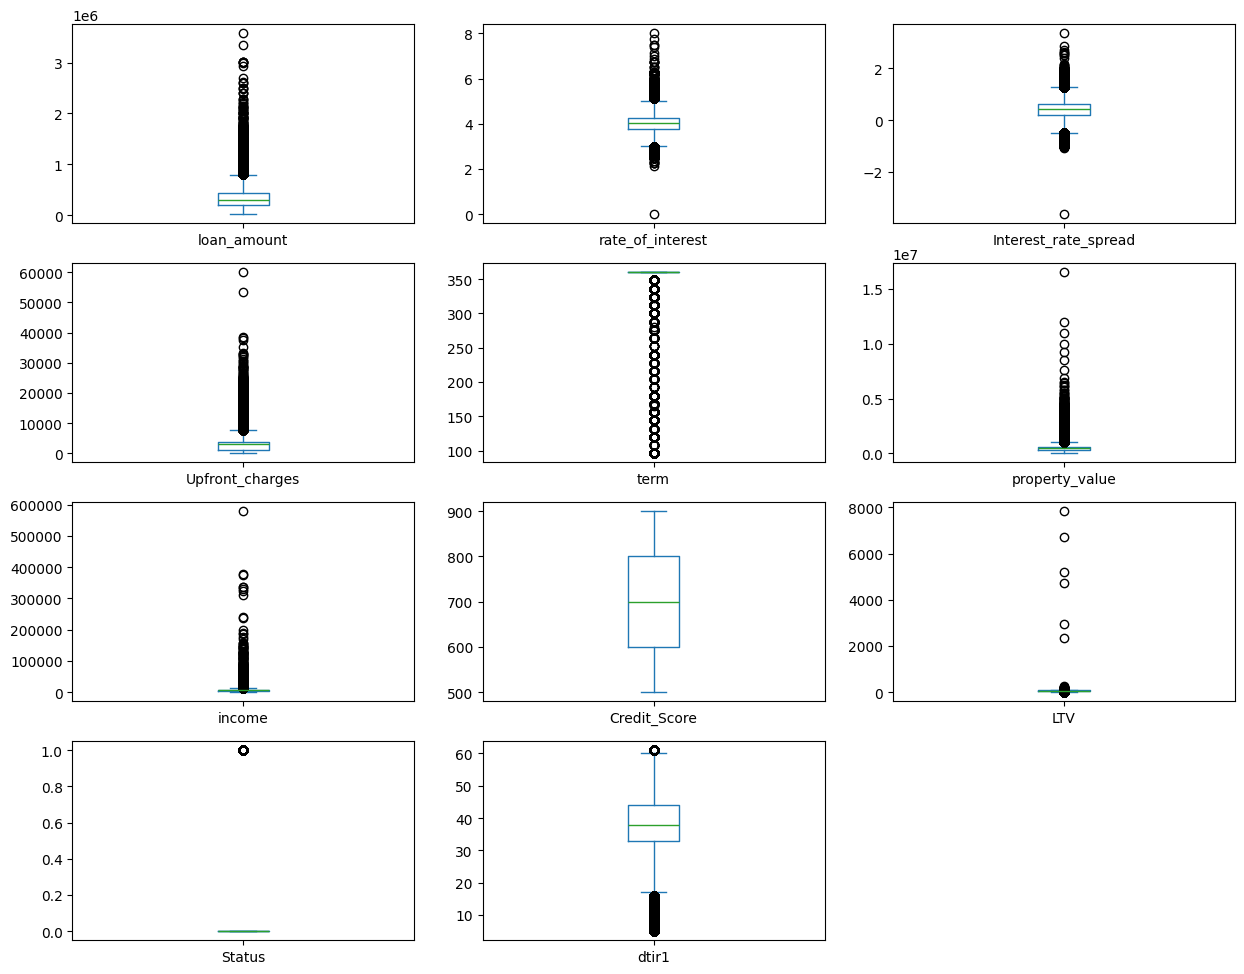

In [ ]:
df.plot(kind="box",subplots=True,layout=(5,3),figsize=(15,15))

## credit_score is only one don't have outliers

In [ ]:
# Select only numeric columns
df1 = df.drop(["Status"], axis=1)
numeric_df = df1.select_dtypes(include=[np.number])

# Calculate quartiles and IQR
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

# Identify outliers
outliers = ((numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR)))

# Remove outliers
df = df[~outliers.any(axis=1)]

# Check the number of outliers removed for each feature
print("Number of outliers removed for each feature:")
print(outliers.sum())


Number of outliers removed for each feature:
loan_amount              1895
rate_of_interest         6817
Interest_rate_spread    11478
Upfront_charges          8915
term                    26985
property_value           6596
income                   7636
Credit_Score                0
LTV                      4671
dtir1                    5508
dtype: int64


,0
loan_amount,"Axes(0.125,0.747241;0.227941x0.132759)"
rate_of_interest,"Axes(0.398529,0.747241;0.227941x0.132759)"
Interest_rate_spread,"Axes(0.672059,0.747241;0.227941x0.132759)"
Upfront_charges,"Axes(0.125,0.587931;0.227941x0.132759)"
term,"Axes(0.398529,0.587931;0.227941x0.132759)"
property_value,"Axes(0.672059,0.587931;0.227941x0.132759)"
income,"Axes(0.125,0.428621;0.227941x0.132759)"
Credit_Score,"Axes(0.398529,0.428621;0.227941x0.132759)"
LTV,"Axes(0.672059,0.428621;0.227941x0.132759)"
Status,"Axes(0.125,0.26931;0.227941x0.132759)"


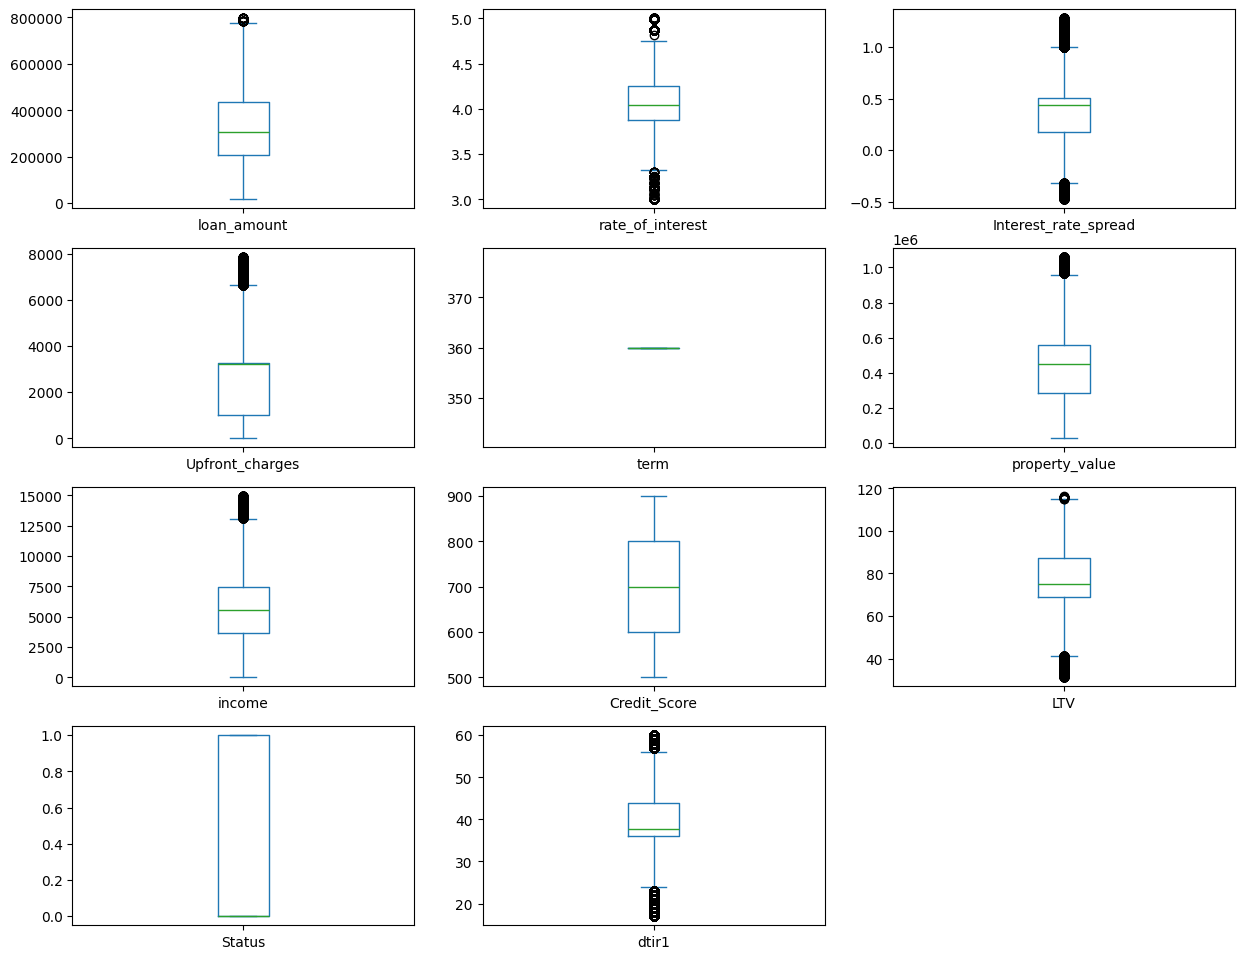

In [ ]:
df.plot(kind="box",subplots=True,layout=(5,3),figsize=(15,15))

In [ ]:
df.Status.unique()

array([1., 0.])

In [ ]:
# adding a new feature
from sklearn.preprocessing import LabelEncoder

label = LabelEncoder()
for i in cat:
    df[i] = label.fit_transform(df[i])



In [ ]:
df

,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,loan_amount,rate_of_interest,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,0,3,0,0,0,0,0,1,116500.0,4.045476,...,3,758.0,0,0,1,98.728814,3,1,1.0,45.000000
1,0,2,0,1,0,0,0,0,206500.0,4.045476,...,2,552.0,1,3,1,72.746457,0,1,1.0,37.732932
2,0,2,1,0,0,0,0,1,406500.0,4.560000,...,3,834.0,0,1,1,80.019685,3,1,0.0,46.000000
3,0,2,0,0,3,0,0,1,456500.0,4.250000,...,3,587.0,0,2,0,69.376900,0,1,0.0,42.000000
4,0,1,1,0,0,0,0,1,696500.0,4.000000,...,1,602.0,1,0,0,91.886544,0,1,0.0,39.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148659,0,3,0,2,2,0,0,1,416500.0,4.375000,...,3,520.0,1,4,1,68.503289,3,1,0.0,40.000000
148660,0,0,0,0,3,0,0,1,366500.0,3.875000,...,0,851.0,1,2,0,55.699088,0,1,0.0,20.000000
148661,0,3,0,1,3,0,0,0,346500.0,4.045476,...,3,585.0,0,0,1,96.787710,3,1,1.0,37.732932
148662,0,1,0,0,3,0,0,1,646500.0,3.625000,...,0,873.0,1,2,0,78.079710,0,1,0.0,31.000000


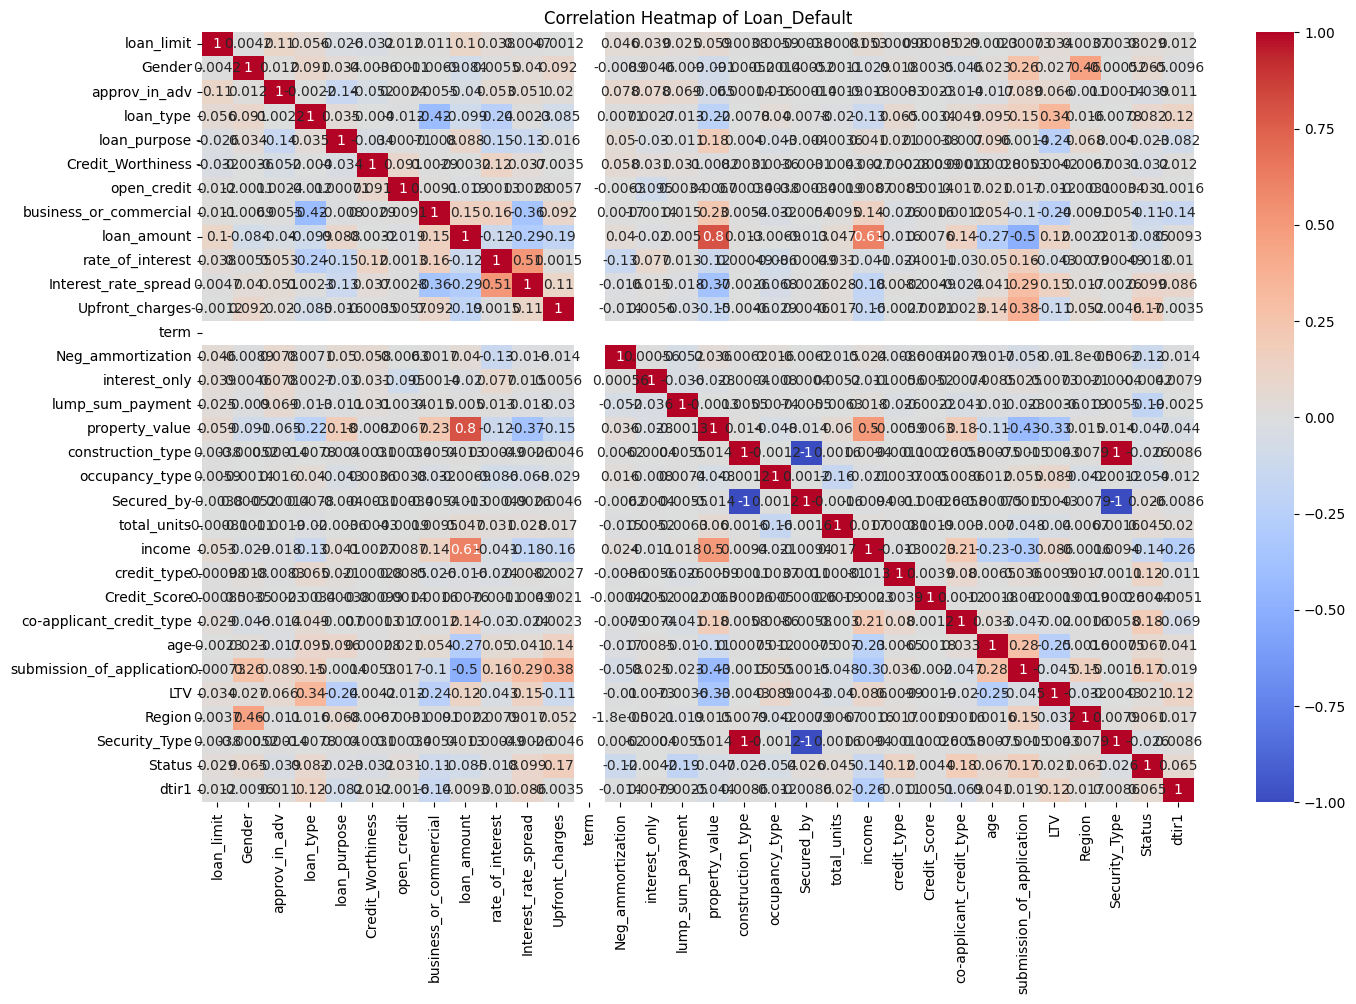

In [ ]:
# heatmap for all features after encoding categorical data
numerical_cols = df.select_dtypes(include=['number'])

# Create a correlation matrix
correlation_matrix = numerical_cols.corr()

# Create a heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Loan_Default')
plt.show()

the data is mostly equalized


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 91006 entries, 0 to 148663
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   loan_limit                 91006 non-null  int64  
 1   Gender                     91006 non-null  int64  
 2   approv_in_adv              91006 non-null  int64  
 3   loan_type                  91006 non-null  int64  
 4   loan_purpose               91006 non-null  int64  
 5   Credit_Worthiness          91006 non-null  int64  
 6   open_credit                91006 non-null  int64  
 7   business_or_commercial     91006 non-null  int64  
 8   loan_amount                91006 non-null  float64
 9   rate_of_interest           91006 non-null  float64
 10  Interest_rate_spread       91006 non-null  float64
 11  Upfront_charges            91006 non-null  float64
 12  term                       91006 non-null  float64
 13  Neg_ammortization          91006 non-null  int64  

In [ ]:
# Get the column names
column_names = df.columns
print(column_names)


Index(['loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose',
       'Credit_Worthiness', 'open_credit', 'business_or_commercial',
       'loan_amount', 'rate_of_interest', 'Interest_rate_spread',
       'Upfront_charges', 'term', 'Neg_ammortization', 'interest_only',
       'lump_sum_payment', 'property_value', 'construction_type',
       'occupancy_type', 'Secured_by', 'total_units', 'income', 'credit_type',
       'Credit_Score', 'co-applicant_credit_type', 'age',
       'submission_of_application', 'LTV', 'Region', 'Security_Type', 'Status',
       'dtir1'],
      dtype='object')


In [ ]:
# Split the dataset into input (X) and output (y)

X = df.drop(["Status"], axis=1)
y = df["Status"]


from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Helper function: Evaluate model

In [ ]:
from sklearn.model_selection import train_test_split,cross_val_score
# Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, KFold
from sklearn.naive_bayes import GaussianNB ,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,roc_auc_score,roc_curve

In [ ]:
def eval_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)
    return acc_train, acc_test

## Function to find the best random state

In [ ]:
def randomstate(x,y):
    maxx=0
    model=LogisticRegression()
    for i in range(1,201):
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=i)
        model.fit(X_train,y_train)
        p=model.predict(X_test)
        accu=accuracy_score(p,y_test)
        if accu>maxx:
            maxx=accu
            j=i
    return j

In [ ]:
randomstate(X,y)

39

## Splitting data into train and test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=39)

## To evaluate performances of all the models

In [ ]:
def performance(p,ytest,m,xtest,s):
    print('------------------------------------',m,'------------------------------------')
    print('Accuracy',np.round(accuracy_score(p,ytest),4))
    print('----------------------------------------------------------')
    print('Mean of Cross validation Score',np.round(s.mean(),4))
    print('----------------------------------------------------------')
    print('AUC_ROC Score',np.round(roc_auc_score(ytest,m.predict_proba(xtest)[:,1]),4))
    print('----------------------------------------------------------')
    print('Confusion Matrix')
    print(confusion_matrix(p,ytest))
    print('----------------------------------------------------------')
    print('Classification Report')
    print(classification_report(p,ytest))

### Creating a list of models which will be created one by one

In [ ]:
models=[GaussianNB(),KNeighborsClassifier(n_neighbors=10),LogisticRegression(),DecisionTreeClassifier(),
        RandomForestClassifier(),XGBClassifier(),BernoulliNB()]

# Creates and trains model from the models list

In [ ]:
def createmodel(X_train, y_train, X_test, y_test):
    for i in models:
        model=i
        model.fit(X_train,y_train)
        p=model.predict(X_test)
        score=cross_val_score(model,X,y,cv=5)
        performance(p,y_test,model,X_test,score)

In [ ]:
createmodel(X_train,y_train,X_test,y_test)

------------------------------------ GaussianNB() ------------------------------------
Accuracy 0.7453
----------------------------------------------------------
Mean of Cross validation Score 0.7418
----------------------------------------------------------
AUC_ROC Score 0.9998
----------------------------------------------------------
Confusion Matrix
[[16393  5795]
 [    0   564]]
----------------------------------------------------------
Classification Report
              precision    recall  f1-score   support

         0.0       1.00      0.74      0.85     22188
         1.0       0.09      1.00      0.16       564

    accuracy                           0.75     22752
   macro avg       0.54      0.87      0.51     22752
weighted avg       0.98      0.75      0.83     22752

------------------------------------ KNeighborsClassifier(n_neighbors=10) ------------------------------------
Accuracy 0.9164
----------------------------------------------------------
Mean of Cross valid

In [ ]:
from sklearn.svm import SVC
acc_SVM = eval_model( SVC(), X_train, y_train, X_test, y_test)
acc_SVM

KeyboardInterrupt: 

# Display models and accuercy score


In [ ]:
acc_knn=eval_model(KNeighborsClassifier(n_neighbors=10), X_train, y_train, X_test, y_test)
acc_log=eval_model(LogisticRegression(), X_train, y_train, X_test, y_test)
acc_rf=eval_model(RandomForestClassifier(), X_train, y_train, X_test, y_test)
acc_gaussian=eval_model(GaussianNB(), X_train, y_train, X_test, y_test)
acc_dt=eval_model(DecisionTreeClassifier(), X_train, y_train, X_test, y_test)
acc_BernoulliNB=eval_model(BernoulliNB(), X_train, y_train, X_test, y_test)

In [ ]:
best_models = pd.DataFrame({
    'Model': ['KNN', 'Logistic Regression',
              'Random Forest', 'Naive Bayes',
              'Decision Tree',#'SVM',
              'BernoulliNB' ],
    'Training Score': [
        '{:.0f}%'.format(acc_knn[0]*100),
        '{:.0f}%'.format(acc_log[0]*100),
        '{:.0f}%'.format(acc_rf[0]*100),
        '{:.0f}%'.format(acc_gaussian[0]*100),
        '{:.0f}%'.format(acc_dt[0]*100),
       # '{:.0f}%'.format(acc_SVM[0]*100),
        '{:.0f}%'.format(acc_BernoulliNB[0]*100),

    ],
    'Testing Score': [
        '{:.0f}%'.format(acc_knn[1]*100),
        '{:.0f}%'.format(acc_log[1]*100),
        '{:.0f}%'.format(acc_rf[1]*100),
        '{:.0f}%'.format(acc_gaussian[1]*100),
        '{:.0f}%'.format(acc_dt[1]*100),
       # '{:.0f}%'.format(acc_SVM[1]*100),
        '{:.0f}%'.format(acc_BernoulliNB[1]*100),
    ]
})

best_models


,Model,Training Score,Testing Score
0,KNN,93%,92%
1,Logistic Regression,75%,76%
2,Random Forest,100%,100%
3,Naive Bayes,74%,75%
4,Decision Tree,100%,100%
5,BernoulliNB,91%,91%


# Clustreing

In [ ]:
from sklearn.cluster import KMeans
cluster_model = KMeans(2)
cluster_model.fit(X)
cluster_y = cluster_model.predict(X)

In [ ]:
y

In [ ]:
k_values = list(range(2, 11))
errors = []

for k in k_values:
    cluster_model = KMeans(k)
    cluster_model.fit(X)
    e = cluster_model.inertia_
    errors.append(e)

In [ ]:
plt.plot(k_values, errors)
plt.title('Elbow method')
plt.xlabel('k')
plt.ylabel('errors')
plt.grid(axis='both')
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

k_values = list(range(2, 11))
scores = []

for k in k_values:
    model = KMeans(k)
    y = model.fit_predict(X)
    s = silhouette_score(X, y)
    scores.append(s)

In [ ]:
plt.plot(k_values, scores)
plt.title('Silhouette method')
plt.xlabel('k')
plt.ylabel('score')
plt.grid(axis='both')
plt.show()

In [ ]:
from sklearn.cluster import KMeans

# Create and fit KMeans
kmeans = KMeans(n_clusters=2)
kmeans.fit(X)

# Assign clusters
predicted_labels = kmeans.predict(X)

# Visualize clusters
for i in range(kmeans.n_clusters):
    plt.scatter(X[predicted_labels == i, 0], X[predicted_labels == i, 1], label=f'Cluster {i}')
    plt.scatter(kmeans.cluster_centers_[i][0], kmeans.cluster_centers_[i][1], s=200, marker='X', color='black')  # centroid

plt.legend()
plt.show()


# Visualize Confusion Matrix

In [ ]:
def plot_conf_matrix(model, X_test, y_test):
    y_pred_test = model.predict(X_test)
    cf = confusion_matrix(y_test, y_pred_test)
    cf_row_sum = cf.sum(axis=1, keepdims=True)
    cf_normalized = cf/cf_row_sum
    sns.heatmap(cf_normalized, annot=True, cmap='Blues')
    plt.show()
    return cf

In [ ]:
def plot_all_models(X_train, y_train, X_test, y_test):
    for i in models:
        model=i
        model.fit(X_train,y_train)
        print('------------------------------------',i,'------------------------------------')
        plot_conf_matrix(model, X_test, y_test)
        print('----------------------------------------------------------------------------------------------\n')

In [ ]:
models=[GaussianNB(),KNeighborsClassifier(n_neighbors=10),LogisticRegression(),DecisionTreeClassifier(),
        RandomForestClassifier(),XGBClassifier(),BernoulliNB()]

------------------------------------ GaussianNB() ------------------------------------


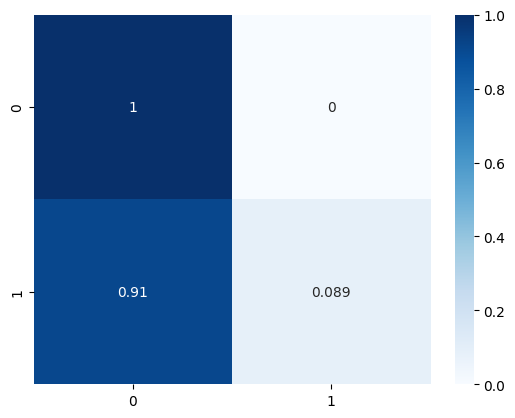

----------------------------------------------------------------------------------------------

------------------------------------ KNeighborsClassifier(n_neighbors=10) ------------------------------------


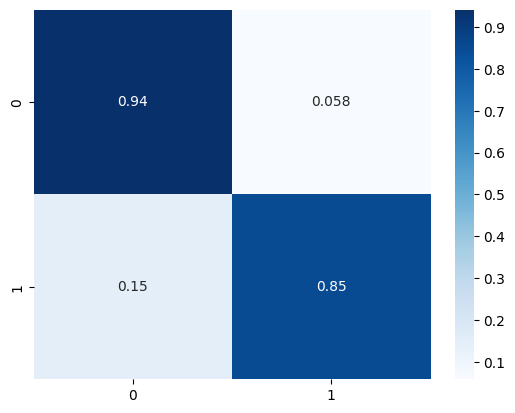

----------------------------------------------------------------------------------------------

------------------------------------ LogisticRegression() ------------------------------------


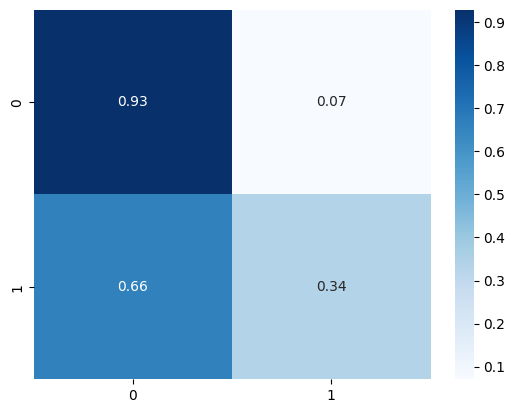

----------------------------------------------------------------------------------------------

------------------------------------ DecisionTreeClassifier() ------------------------------------


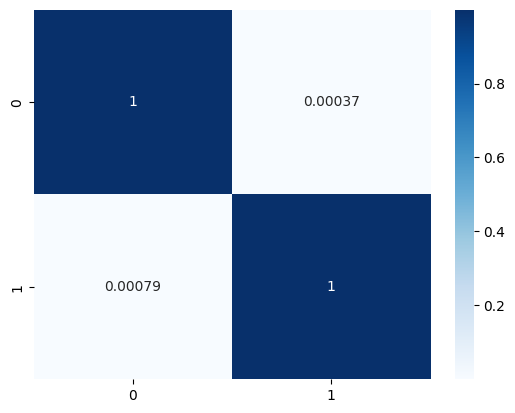

----------------------------------------------------------------------------------------------

------------------------------------ RandomForestClassifier() ------------------------------------


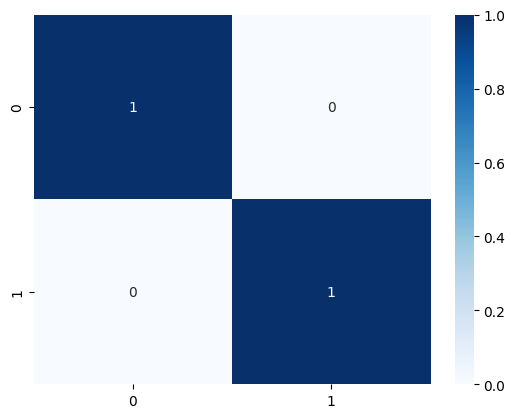

----------------------------------------------------------------------------------------------

------------------------------------ XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...) ------------------------------------


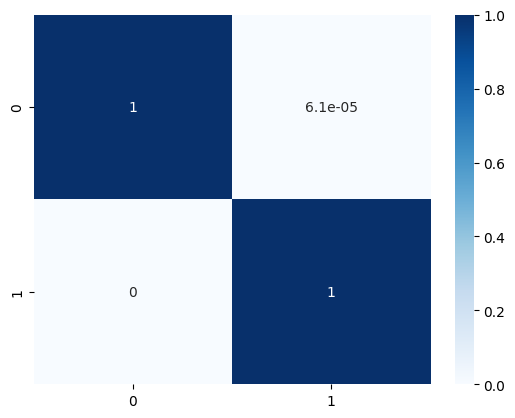

----------------------------------------------------------------------------------------------

------------------------------------ BernoulliNB() ------------------------------------


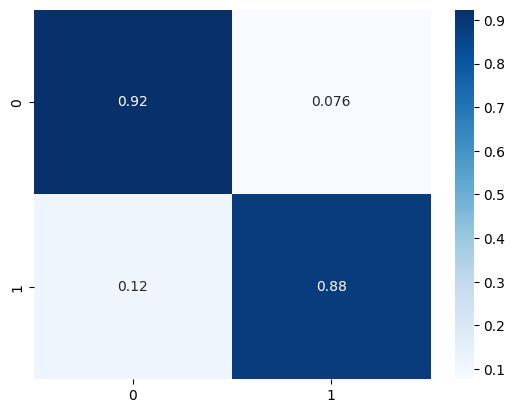

----------------------------------------------------------------------------------------------



In [ ]:
plot_all_models(X_train, y_train, X_test, y_test)

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def plot_roc_curve(model, X_test, y_test):
    # Predict probabilities
    y_probs = model.predict_proba(X_test)[:, 1]

    # Calculate fpr, tpr, thresholds
    fpr, tpr, thresholds = roc_curve(y_test, y_probs)

    # Calculate AUC (Area Under the Curve)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve
    plt.figure()
    lw = 2
    plt.plot(fpr, tpr, color='darkorange', lw=lw, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()

    return fpr, tpr, thresholds


In [ ]:
def plot_all_roc_curve(X_test, y_test):
    for i in models:
        model=i
        print('------------------------------------',i,'------------------------------------')
        plot_roc_curve(model, X_test, y_test)
        print('----------------------------------------------------------------------------------------------\n')

------------------------------------ GaussianNB() ------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning:

X has feature names, but GaussianNB was fitted without feature names



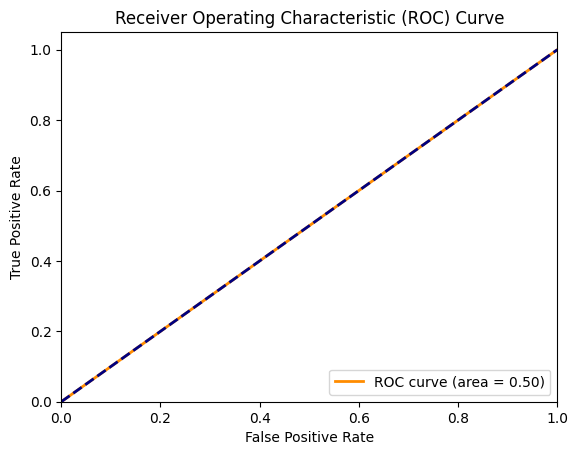

----------------------------------------------------------------------------------------------

------------------------------------ KNeighborsClassifier(n_neighbors=10) ------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning:

X has feature names, but KNeighborsClassifier was fitted without feature names



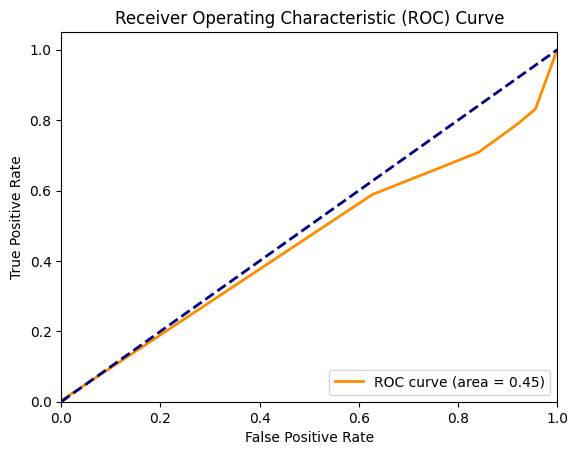

----------------------------------------------------------------------------------------------

------------------------------------ LogisticRegression() ------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning:

X has feature names, but LogisticRegression was fitted without feature names



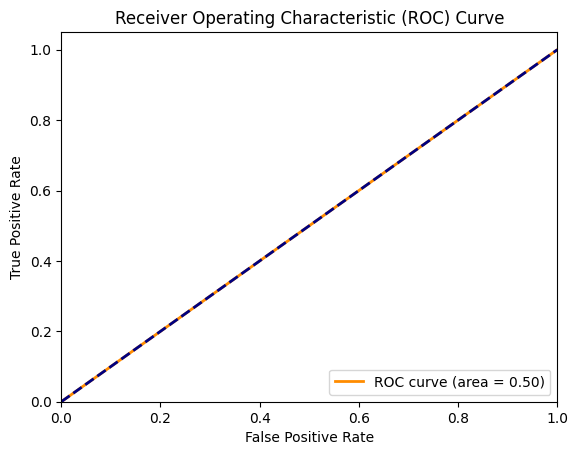

----------------------------------------------------------------------------------------------

------------------------------------ DecisionTreeClassifier() ------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning:

X has feature names, but DecisionTreeClassifier was fitted without feature names



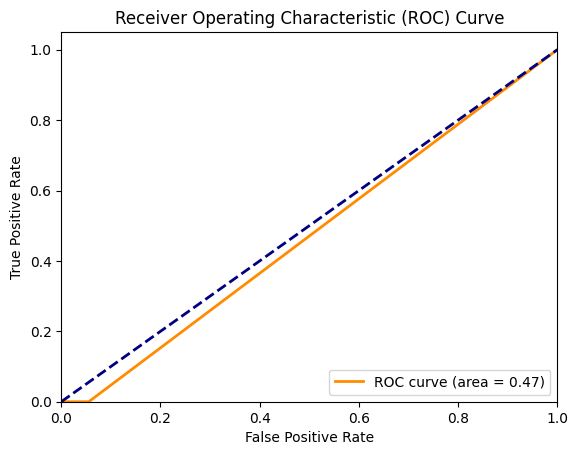

----------------------------------------------------------------------------------------------

------------------------------------ RandomForestClassifier() ------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning:

X has feature names, but RandomForestClassifier was fitted without feature names



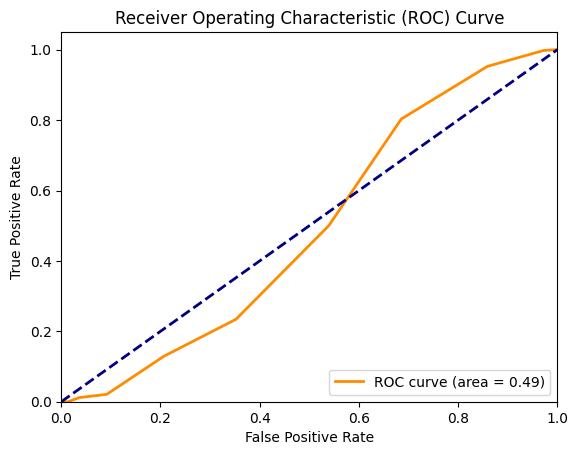

----------------------------------------------------------------------------------------------

------------------------------------ XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...) ------------------------------------


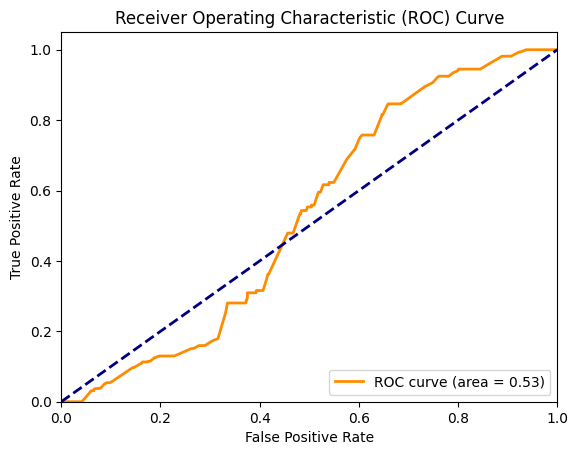

----------------------------------------------------------------------------------------------

------------------------------------ BernoulliNB() ------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning:

X has feature names, but BernoulliNB was fitted without feature names



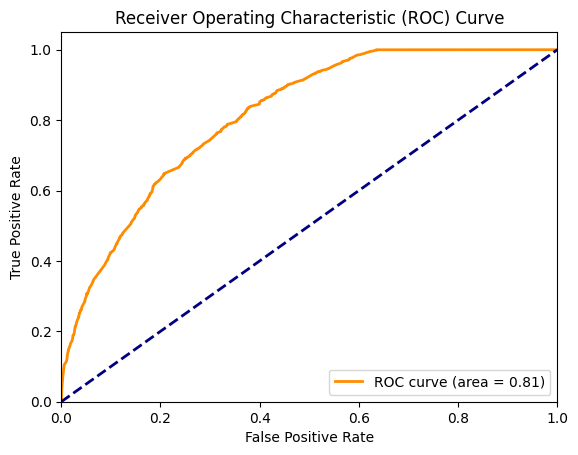

----------------------------------------------------------------------------------------------



In [ ]:
plot_all_roc_curve(X_test, y_test)